## Data and Setup

Please Note: This project was developed and tested in a Google Colab environment.

### Data Loader

In [ ]:
import pandas as pd
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Data Reproducibility

In [ ]:
import numpy as np
import pandas as pd
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Data Quality Notes (Esha)

**1. Missing Values:**

In [ ]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(df)
print(missing_values_series)

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


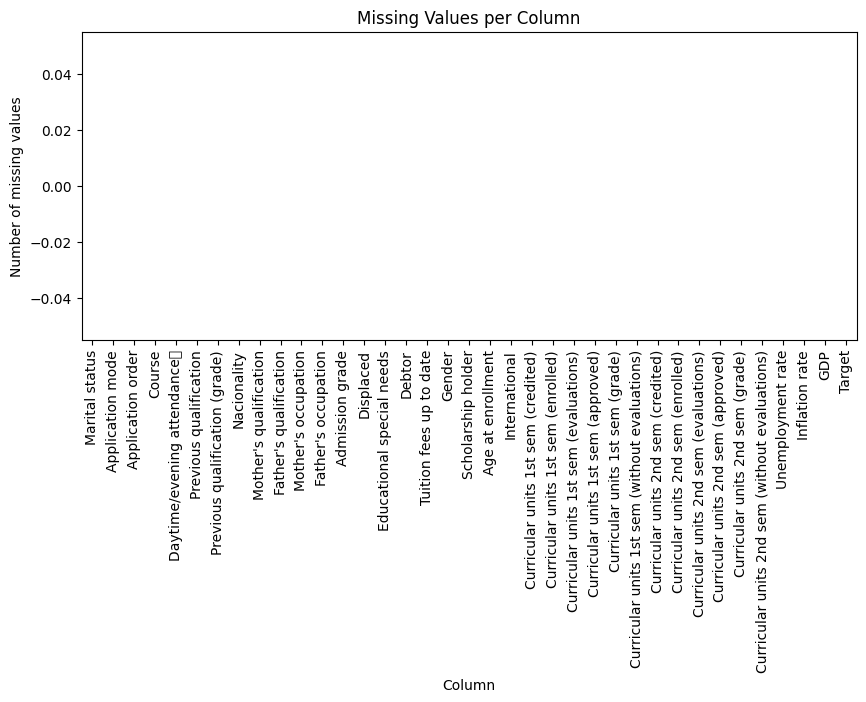

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
missing_values_series.plot(kind='bar', color='yellow')
plt.title('Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Number of missing values')
plt.show()

Missing value analysis showed that no missing values were detected  for any of the features in the dataset.



**2. Odd Values:**

In [ ]:
valid_martial_status_codes = {1,2,3,4,5,6}
application_mode_codes = {1,2,5,7,10,15,16,17,18,26,27,39,42,43,44,51,53,57}
application_order_codes = {0,1,2,3,4,5,6,7,8,9}
course_codes = {33,171,8014,9003,9070,9085,9119,9130,9147,9238,9254,9500,9556,9670,9773,9853,9991}
valid_0_or_1 = {0,1}
previous_qualification_codes = {1,2,3,4,5,6,9,10,12,14,15,19,38,39,40,42,43}
nacionality = {1,2,6,11,13,14,17,21,22,24,25,26,32,41,62,100,101,103,105,108,109}
mom_qualifications = {1,2,3,4,5,6,9,10,11,12,14,18,19,22,26,27,29,30,34,35,36,37,38,39,40,41,42,43,44}
dad_qualifications = {1,2,3,4,5,6,9,10,11,12,13,14,18,19,20,22,25,26,27,29,30,31,33,34,35,36,37,38,39,40,41,42,43,44}
mom_occupation = {0,1,2,3,4,5,6,7,8,9,10,90,99,122,123,125,131,132,134,141,143,144,151,152,153,171,173,175,191,192,193,194}
dad_occupation = {0,1,2,3,4,5,6,7,8,9,10,90,99,101,102,103,112,114,121,122,123,124,131,132,134,135,141,143,144,151,152,153,154,161,163,171,172,174,175,181,182,183,192,193,194,195}





columns_to_check = {"Marital status": valid_martial_status_codes,
    "Application mode": application_mode_codes,
    "Application order": application_order_codes,
    "Course": course_codes,
    'Daytime/evening attendance\t': valid_0_or_1,

    "Nacionality": nacionality,
    "Mother's qualification": mom_qualifications,
    "Father's qualification": dad_qualifications,
    "Mother's occupation": mom_occupation,
    "Father's occupation": dad_occupation,
    "Displaced": valid_0_or_1,
    "Educational special needs": valid_0_or_1,
    "Debtor": valid_0_or_1,
    'Tuition fees up to date': valid_0_or_1,
    "Gender": valid_0_or_1,
    'Scholarship holder': valid_0_or_1,
    "International": valid_0_or_1}


columns_with_range = {
    "Previous qualification (grade)": (0,200),
    "Admission grade": (0,200),
    "Curricular units 1st sem (grade)": (0,20),
    "Curricular units 2nd sem (grade)": (0,20)}


def find_invalid_values (df, column, valid_set):
  # Returns all values in df[column] that are not int valid set
  unique_values = set(df[column].unique())
  invalid = unique_values - valid_set
  return invalid

def find_invalid_range(df, column, min_val, max_val):
  invalid_values = df[(df[column] < min_val) | (df[column] > max_val)][column].unique()
  return invalid_values


print("Non Range Odd Value Check:")
for col, valid in columns_to_check.items():
  invalid = find_invalid_values(df, col, valid)
  if len(invalid)>0:
    print(f"{col}: invalid values found: {invalid}")
    print()
  else:
    print(f"{col}: all good")
    print()

  print("Range Odd Value Check:")
for col, (low, high) in columns_with_range.items():
  invalid = find_invalid_range(df, col, low, high)
  if len(invalid)>0:
    print(f"{col}: invalid values found: {invalid}")
    print()
  else:
    print(f"{col}: all good")
    print()



Non Range Odd Value Check:
Marital status: all good

Range Odd Value Check:
Application mode: all good

Range Odd Value Check:
Application order: all good

Range Odd Value Check:
Course: all good

Range Odd Value Check:
Daytime/evening attendance	: all good

Range Odd Value Check:
Nacionality: all good

Range Odd Value Check:
Mother's qualification: all good

Range Odd Value Check:
Father's qualification: all good

Range Odd Value Check:
Mother's occupation: all good

Range Odd Value Check:
Father's occupation: all good

Range Odd Value Check:
Displaced: all good

Range Odd Value Check:
Educational special needs: all good

Range Odd Value Check:
Debtor: all good

Range Odd Value Check:
Tuition fees up to date: all good

Range Odd Value Check:
Gender: all good

Range Odd Value Check:
Scholarship holder: all good

Range Odd Value Check:
International: all good

Range Odd Value Check:
Previous qualification (grade): all good

Admission grade: all good

Curricular units 1st sem (grade): al

An odd value analysis was performed by comparing all categorical features with their valid code lists, which resulted in no odd values being discovered. Then, continuous features were checked for out-of-range values and the results found that all values were within the expected limits.

**3. Duplicate Instances:**

In [ ]:
# Counts how many duplicate rows there are
duplicate_count = df.duplicated().sum()

# Collects the duplicated rows into a list called duplicate_rows
duplicate_rows = df[df.duplicated()].to_dict(orient='records')

# Checks whether any duplicates exist
if duplicate_count > 0:
  print("Number of duplicate rows: ", duplicate_count)
  print("Duplicated rows:")
  # row is created
  for row in duplicate_rows:
    # prints each row in duplicate_rows on a new line
    print(row)
else:
  print("No duplicate rows")

No duplicate rows


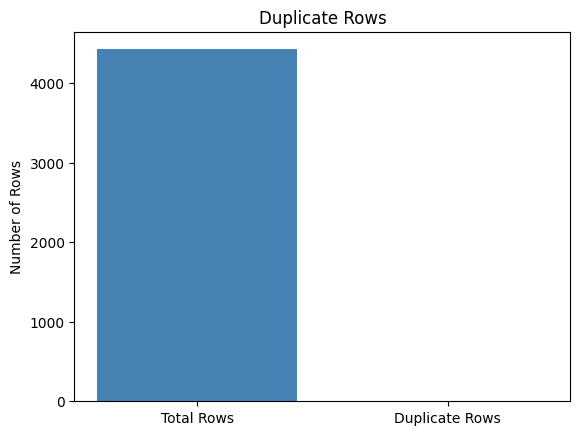

In [ ]:
import matplotlib.pyplot as plt

total_rows = len(df)
duplicate_count = df.duplicated().sum()

plt.bar(["Total Rows", "Duplicate Rows"], [total_rows, duplicate_count], color=["steelblue"])
plt.title("Duplicate Rows")
plt.ylabel("Number of Rows")
plt.show()

Duplicate row analysis showed that no duplicate rows were detected in the dataset.

**4. Outliers:**

In [ ]:
from numpy._core.defchararray import lower
continuous_features = ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
                       'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
                       'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

def outlier_identification_iqr (df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

  return outliers, lower_bound, upper_bound


for col in continuous_features:
  outliers, lb, ub = outlier_identification_iqr(df, col)
  print(f"{col}: {len(outliers)} outliers (lower={lb:.2f}, upper={ub:.2f})")

Admission grade: 86 outliers (lower=92.55, upper=160.15)
Previous qualification (grade): 179 outliers (lower=102.50, upper=162.50)
Age at enrollment: 441 outliers (lower=10.00, upper=34.00)
Curricular units 1st sem (credited): 577 outliers (lower=0.00, upper=0.00)
Curricular units 1st sem (enrolled): 424 outliers (lower=2.00, upper=10.00)
Curricular units 1st sem (evaluations): 158 outliers (lower=0.00, upper=16.00)
Curricular units 1st sem (approved): 180 outliers (lower=-1.50, upper=10.50)
Curricular units 1st sem (grade): 726 outliers (lower=7.40, upper=17.00)
Curricular units 1st sem (without evaluations): 294 outliers (lower=0.00, upper=0.00)
Curricular units 2nd sem (credited): 530 outliers (lower=0.00, upper=0.00)
Curricular units 2nd sem (enrolled): 369 outliers (lower=2.00, upper=10.00)
Curricular units 2nd sem (evaluations): 109 outliers (lower=0.00, upper=16.00)
Curricular units 2nd sem (approved): 44 outliers (lower=-4.00, upper=12.00)
Curricular units 2nd sem (grade): 877 

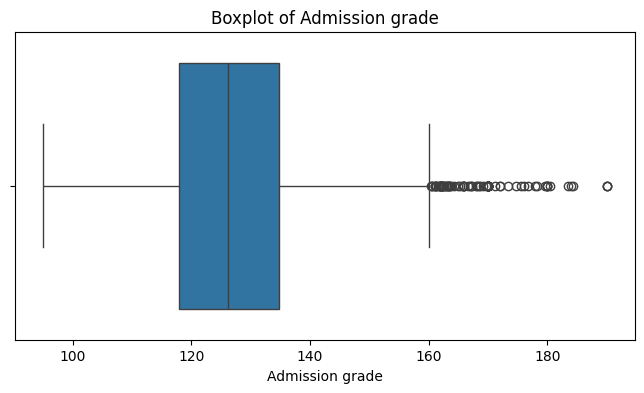

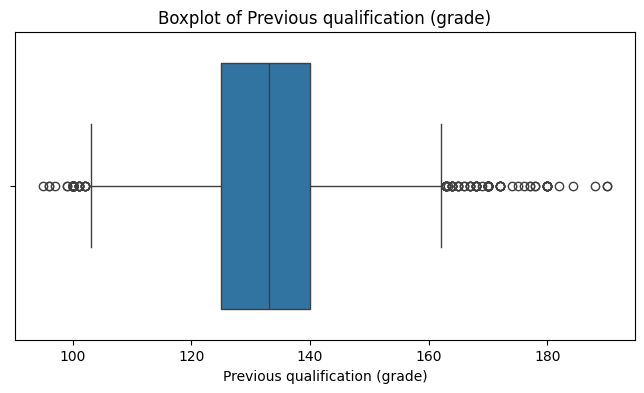

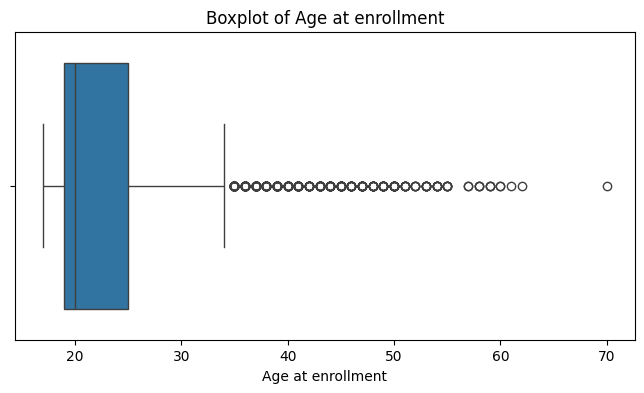

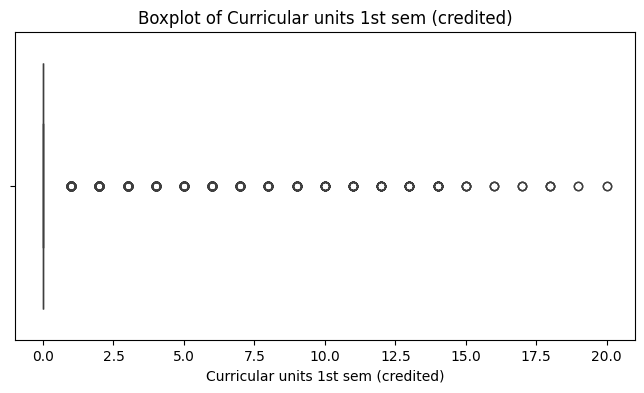

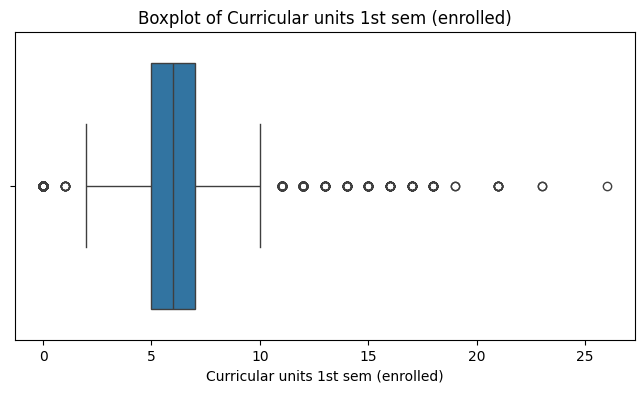

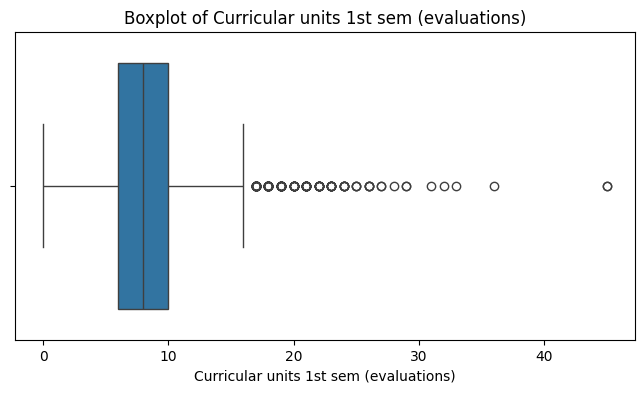

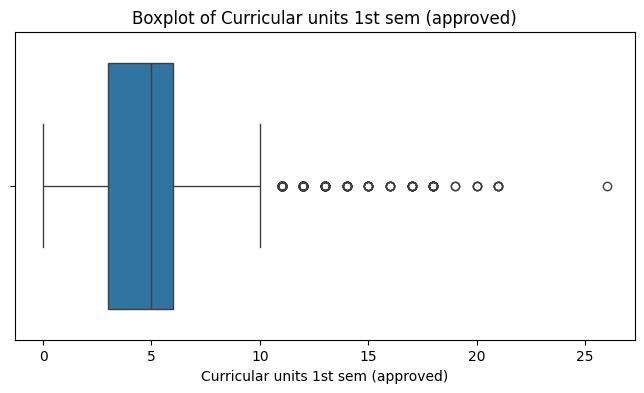

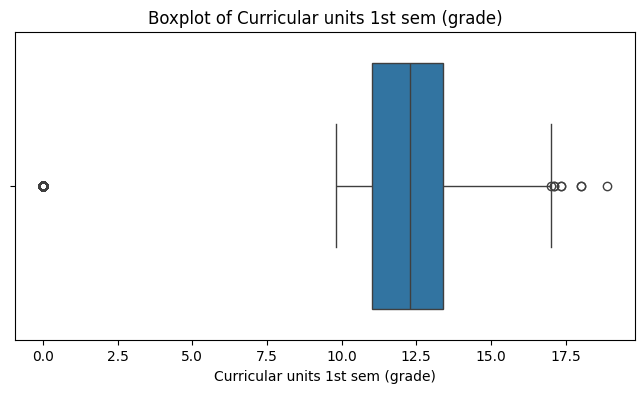

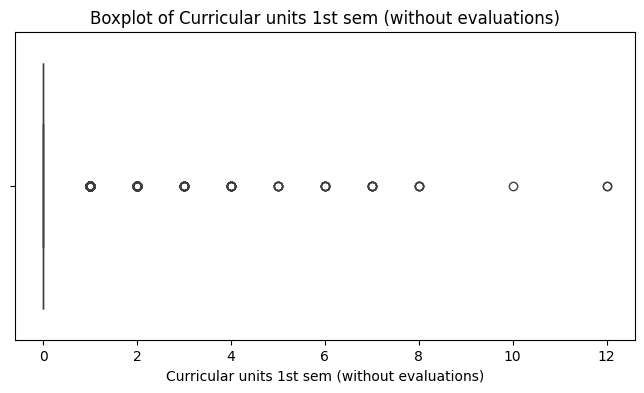

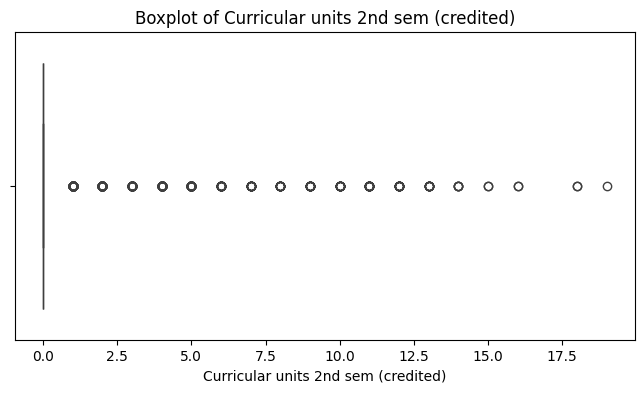

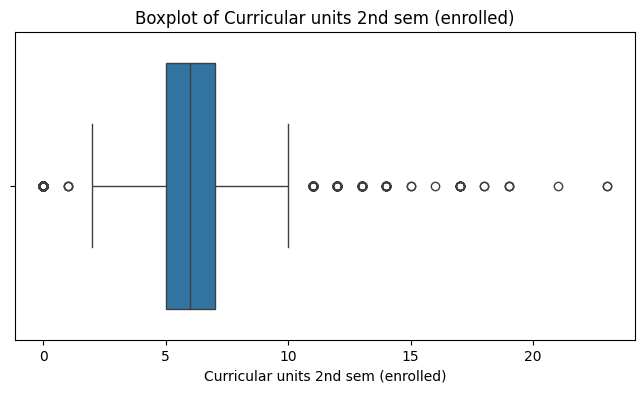

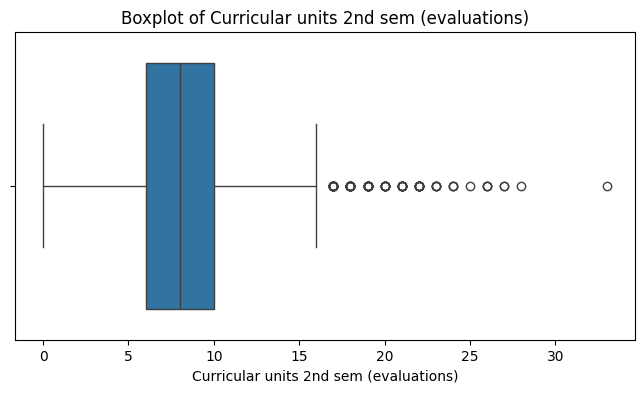

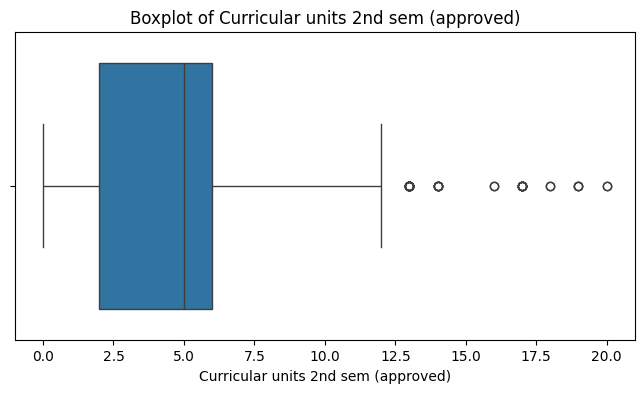

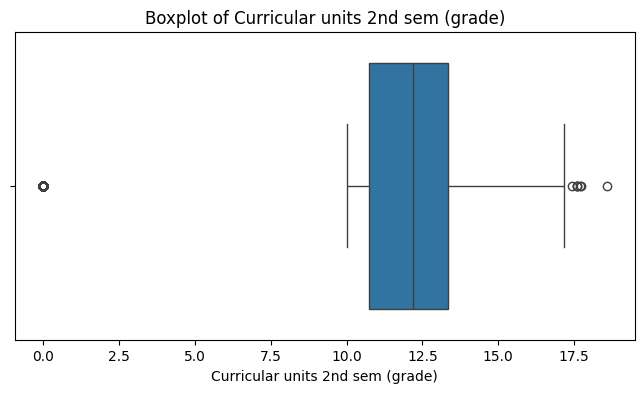

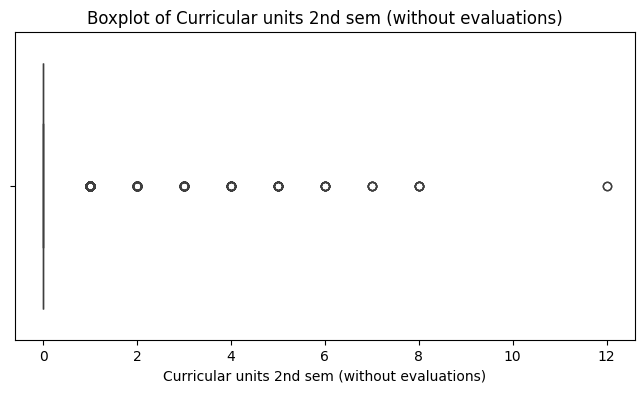

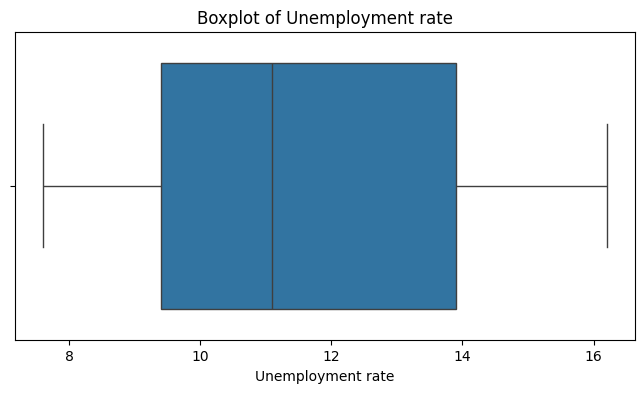

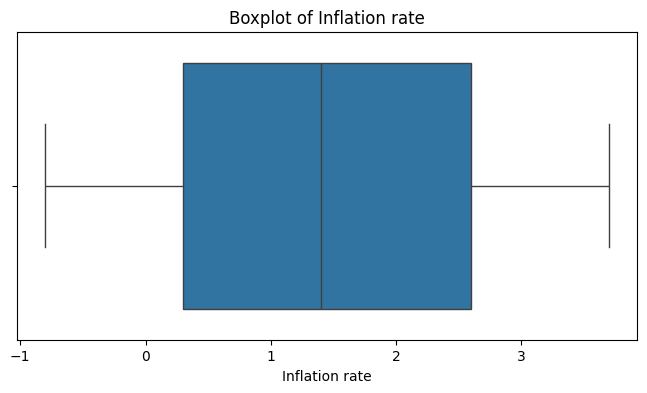

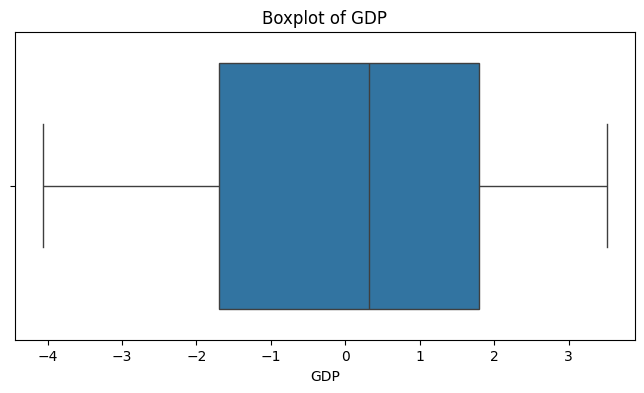

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_features:
  plt.figure(figsize=(8,4))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

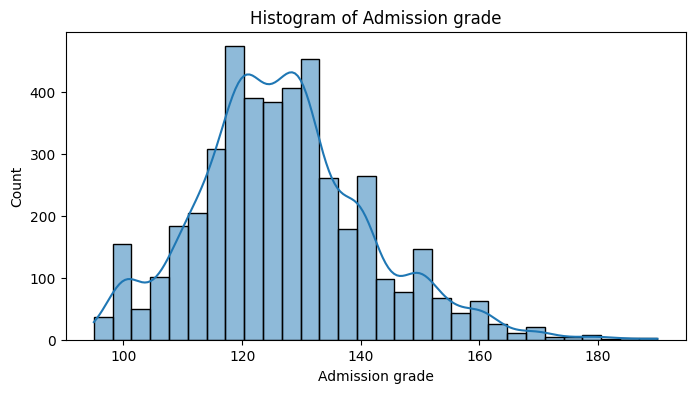

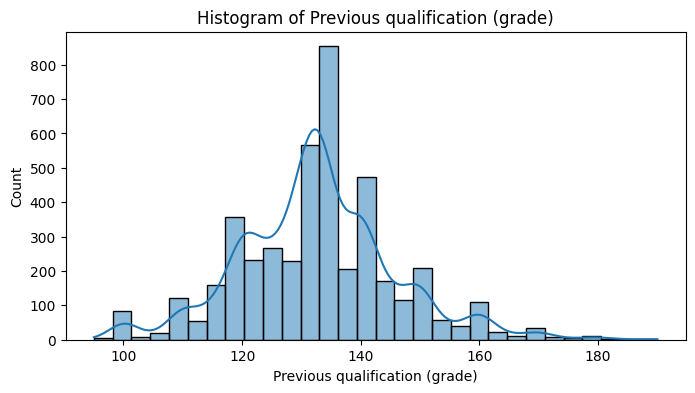

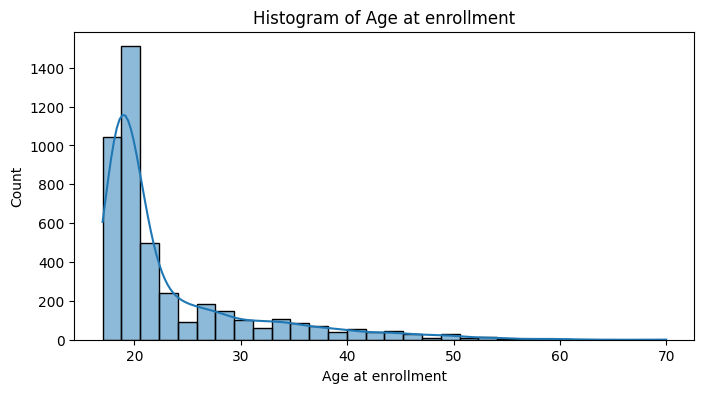

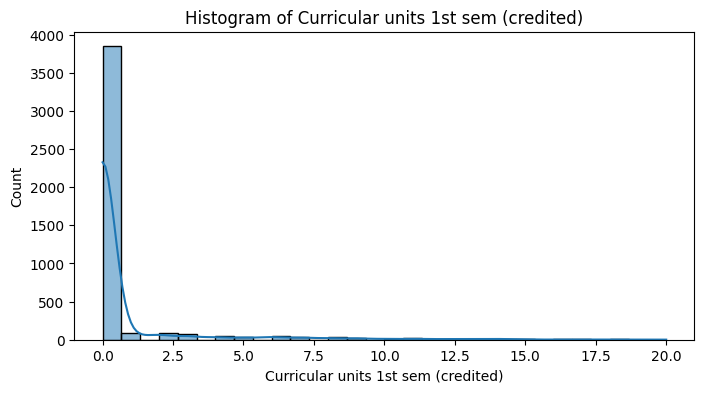

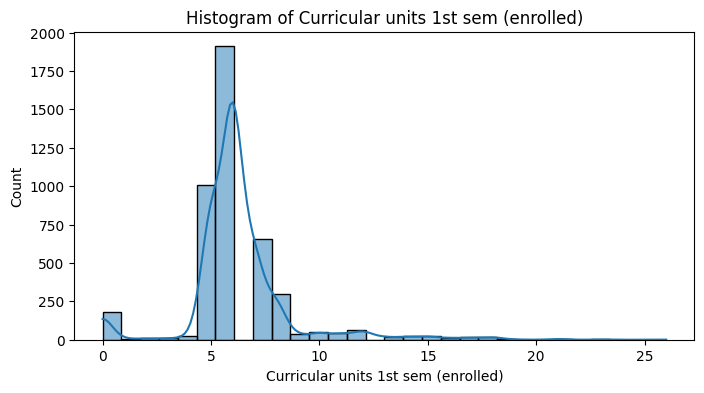

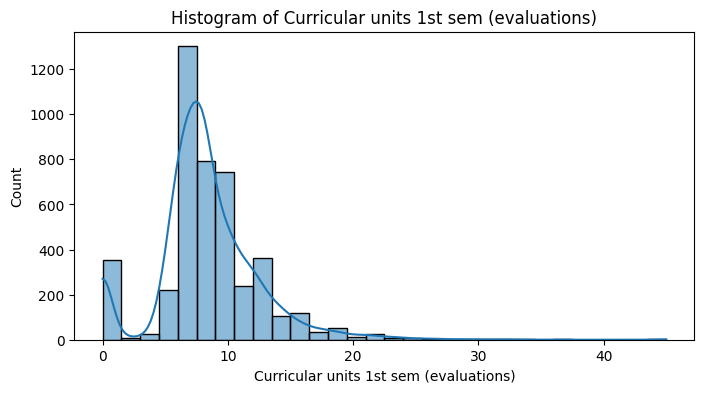

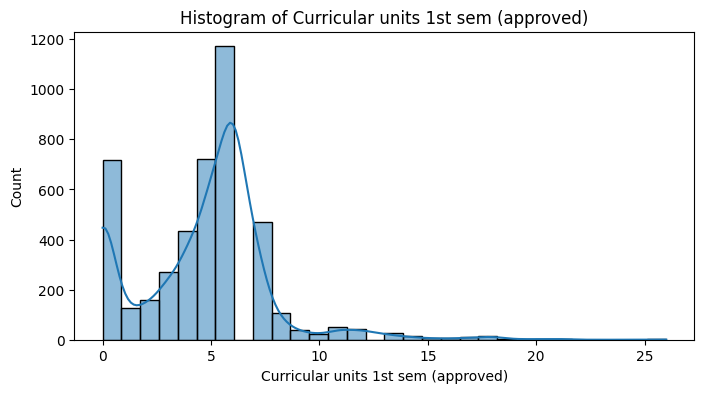

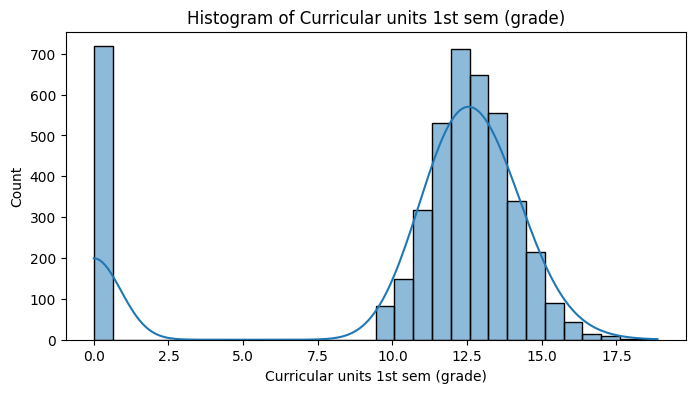

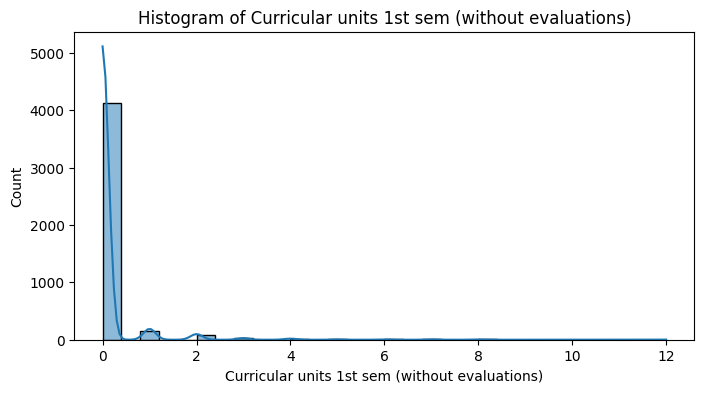

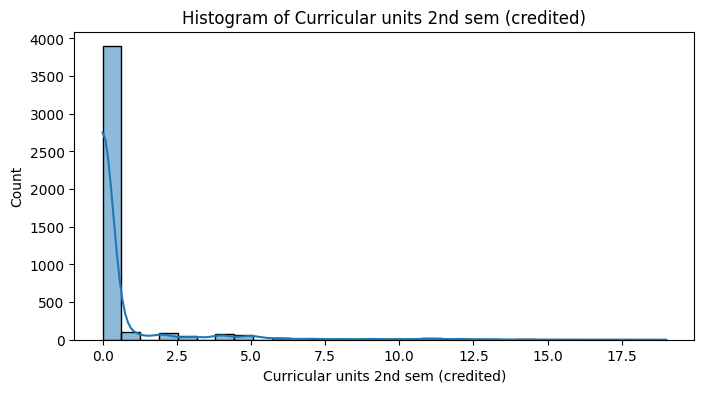

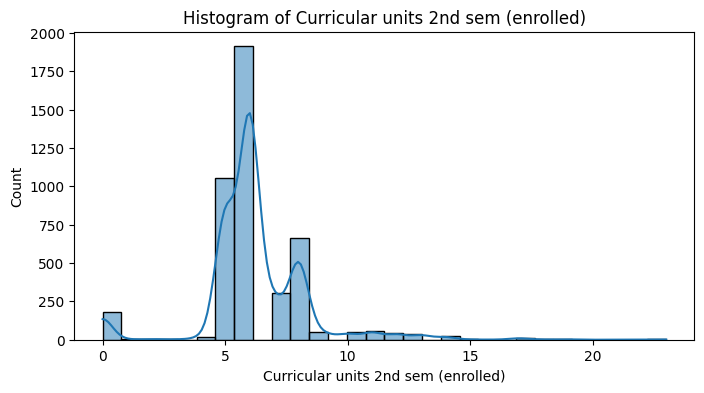

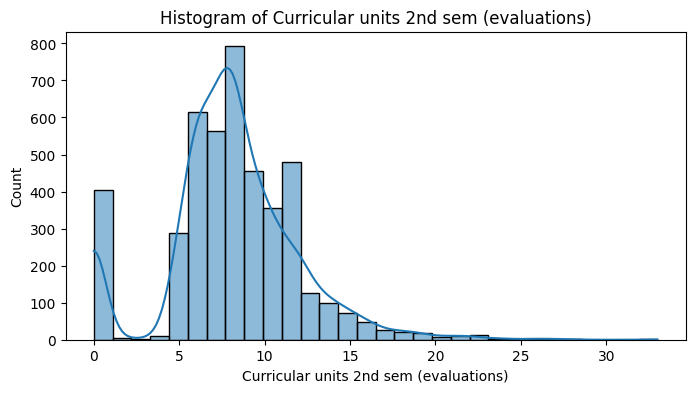

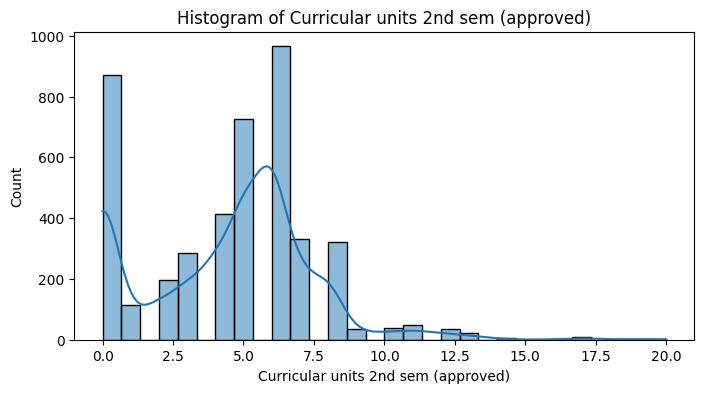

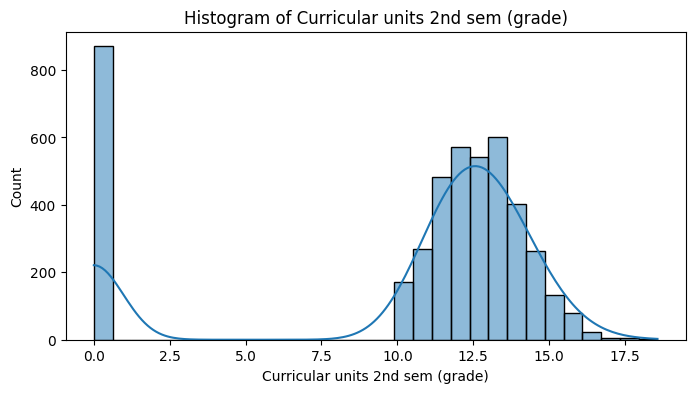

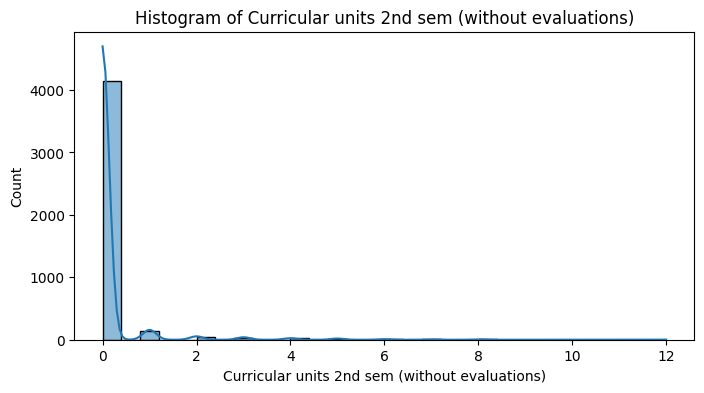

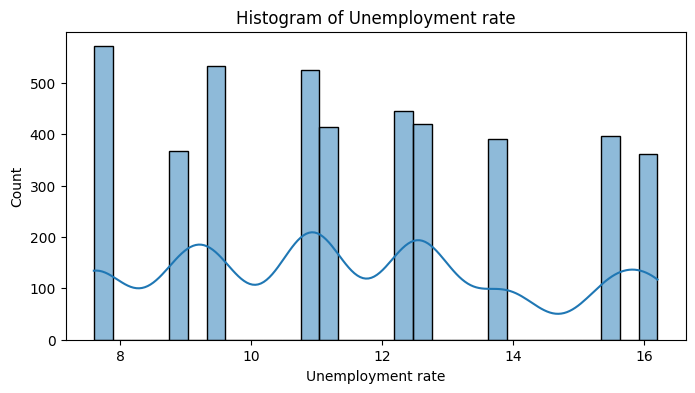

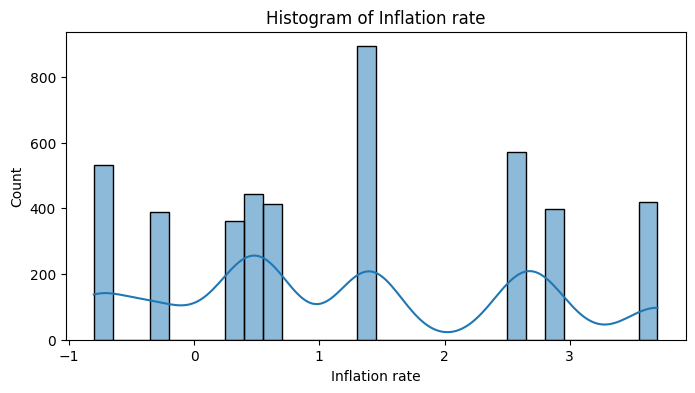

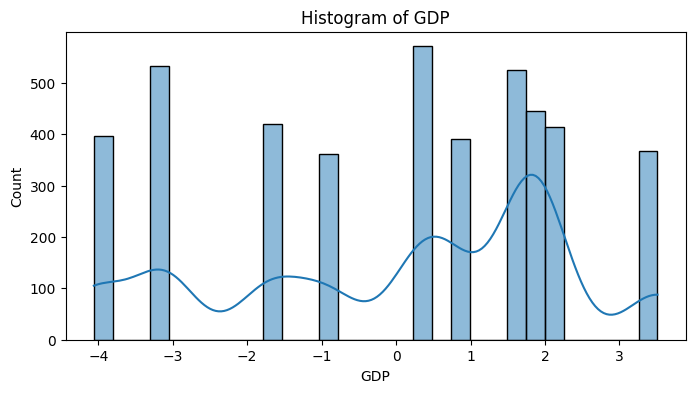

In [ ]:
for col in continuous_features:
  plt.figure(figsize=(8, 4))
  sns.histplot(df[col], kde=True, bins=30)
  plt.title(f'Histogram of {col}')
  plt.show()

In [ ]:
focus_cols = [col for col in ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
                       'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
                       'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP'] if col in df.columns]
iqr_rows = []

for col in focus_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    iqr_rows.append({
        'column': col,
        'q1': float(q1),
        'q3': float(q3),
        'iqr': float(iqr),
        'lower_fence': float(lower),
        'upper_fence': float(upper),
        'outlier_count': int(mask.sum()),
        'outlier_pct': float(mask.mean() * 100)
    })

global_outlier_summary = pd.DataFrame(iqr_rows).sort_values('outlier_pct', ascending=False)
print("Global IQR outlier summary:")
display(global_outlier_summary)

Global IQR outlier summary:


,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
13,Curricular units 2nd sem (grade),10.75,13.333333,2.583333,6.875,17.208333,877,19.823689
7,Curricular units 1st sem (grade),11.00,13.400000,2.400000,7.400,17.000000,726,16.410488
3,Curricular units 1st sem (credited),0.00,0.000000,0.000000,0.000,0.000000,577,13.042495
9,Curricular units 2nd sem (credited),0.00,0.000000,0.000000,0.000,0.000000,530,11.980108
2,Age at enrollment,19.00,25.000000,6.000000,10.000,34.000000,441,9.968354
4,Curricular units 1st sem (enrolled),5.00,7.000000,2.000000,2.000,10.000000,424,9.584087
10,Curricular units 2nd sem (enrolled),5.00,7.000000,2.000000,2.000,10.000000,369,8.340868
8,Curricular units 1st sem (without evaluations),0.00,0.000000,0.000000,0.000,0.000000,294,6.645570
14,Curricular units 2nd sem (without evaluations),0.00,0.000000,0.000000,0.000,0.000000,282,6.374322
6,Curricular units 1st sem (approved),3.00,6.000000,3.000000,-1.500,10.500000,180,4.068716


Outlier detection was carried out only on continuous numeric features, as these represent measurable quantities where unusually high or low values may indicate data anomalies. For each continuous numeric feature, the IQR method was employed and was supported by boxplots and histograms to inspect distribution shapes. The IQR results showed all academic performance features being flagged with having outliers, whereas, the economic/financial features (GDP, Inflation rate, Unemployment rate) showed no outliers and had stable, typical distribution shapes in the graphs as well. Although every continuous feature (academic performance and economic/financial) was examined and graphed (histogram and boxplot), most academic performance features had similar distribution patterns. Therefore, in order to avoid repetition by going through each of the 15 academic performance feature results -  to keep the analysis focused, only the notable patterns seen across the features - such as zero inflation and right skewed distribution are explained further.


Zero Inflation:  

Histogram and Boxplot for Curricular units 1st sem (credited)

Histogram:
There is a strong zero-inflated distribution, where the majority of students credited zero units.

Boxplot:
The zero inflation is further shown when the boxplot collapses to a single line at zero, since the whiskers cannot extend beyond zero as a result of Q1,Q3, lower fence, and upper fence all equaling zero. Since the IQR is zero, it forces all non zero values to appear as dots behind the line. All of these dots are not outliers (i.e., data errors or impossible situations) but instead represent the non zero portion of a zero inflated feature.

Overall:
On that note, although the Global IQR summary flagged 577 outliers, after looking at the histogram and boxplot, it was determined that these values represent possible student behaviours. Therefore, no outliers were removed.



Right Skewed Distribution:

Histogram and Boxplot for Age at Enrollment

Histogram:
There is a right skewed distribution, with most students at the time of enrollment being between the ages of 18 and 20 and a smaller number of mature students extending the tail to the right.

Boxplot:
On that note, the right skewed distribution, where Q1 and Q3 fall within the majority age, and the whiskers go from the youngest to the oldest ages that fall within the lower and upper fences.  Hence, the dots are not outliers (i.e., data errors or impossible situations) however instead represent uncommon but possible ages for enrollment.

Overall:
With that said, although the Global IQR summary flagged 441 outliers, after looking at the histogram and boxplot, it was determined that these values represent possible student ages. Therefore, no outliers were removed.


Zero Inflation and Right Skewed Upper Tail:

Histogram and Boxplot for Curricular units 1st sem (grade)     


Histogram:
Curricular units 1st sem (grade) displays both a strong zero-inflation as well as a right skewed upper tail. The large spike at zero displays a zero-inflation representing many students who received no grades, while the values around 11 to 14 represent the main grade cluster. The values from the main grade cluster slowly flatten out forming a right skewed upper tail.

Boxplot:
Shows how the Q1 and Q3 fall within the main grade cluster, so the lower whisker extends to the smallest non-zero grade (the lower fence), while the upper whisker extends to the highest value (the upper fence). Since, the lower fence is above zero (7.4), all zero grades fall below the lower fence, as they are depicted as a single dark dot, which represents many values. On the other end, grades that are higher than the upper fence are also flagged, resulting in some dots after the upper whisker. All of these dots in Figure 10 are not outliers (i.e., data errors or impossible situations) but instead represent possible student behaviours.

Overall:
On that note, although the Global IQR summary flagged 726 outliers, after looking at the histogram and boxplot, it was determined that these values represent possible student behaviours. Therefore, no outliers were removed.


# Meaningful EDA Insights (Talha)

**Enrollment Age vs Target Outcome**

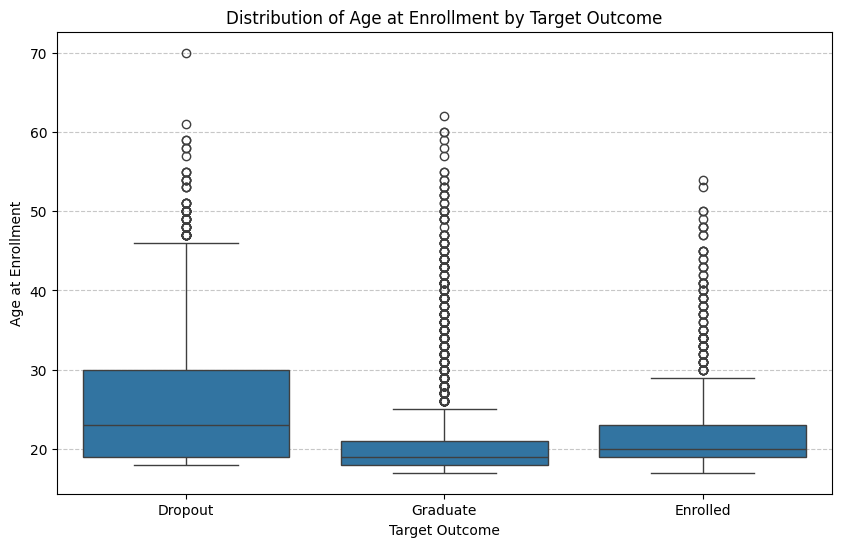

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a mapping from encoded target values back to original labels
# Assuming label_encoder is still available from previous steps
if 'label_encoder' in locals():
    target_labels = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
    df['Target_Label'] = df['Target'].map(target_labels)
else:
    # Fallback if label_encoder is not found, though it should be after previous steps
    print("Warning: label_encoder not found. Using numerical target values.")
    df['Target_Label'] = df['Target']

plt.figure(figsize=(10, 6))
sns.boxplot(x='Target_Label', y='Age at enrollment', data=df)
plt.title('Distribution of Age at Enrollment by Target Outcome')
plt.xlabel('Target Outcome')
plt.ylabel('Age at Enrollment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Of the three Target outcomes, data is much more narrowly distributed for Graduates and Current Students. Data is highly skewed to indicate a young Student Body but with a greater number of older students at risk of dropping out.

**Outcome vs Scholarship Status**

<Figure size 1000x700 with 0 Axes>

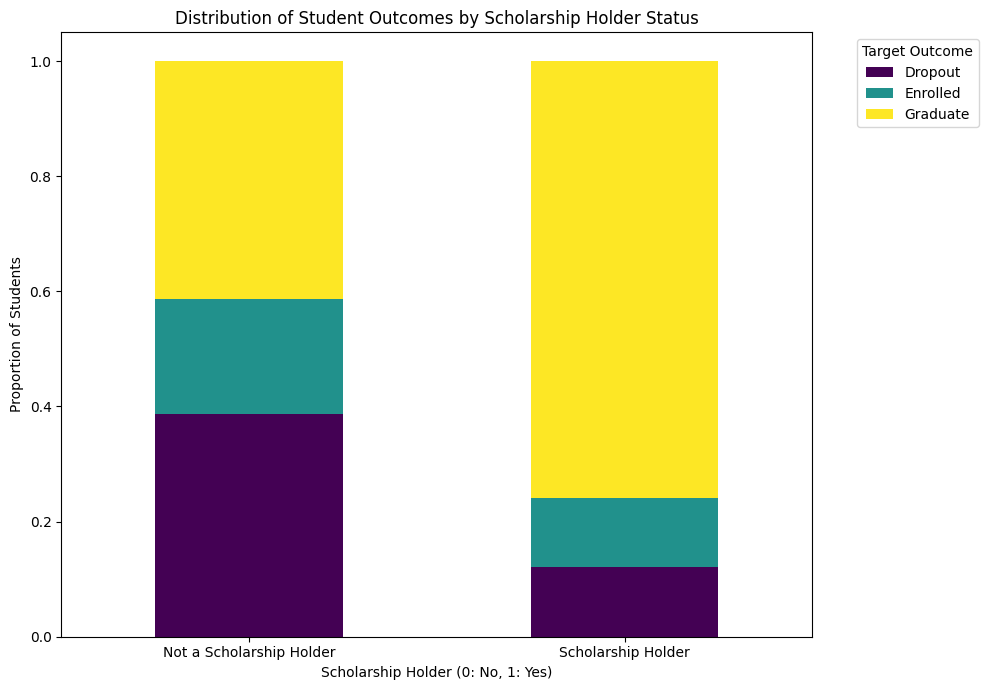

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation to get counts of Target_Label for each Scholarship Holder status
scholarship_target_counts = pd.crosstab(df['Scholarship holder'], df['Target_Label'], normalize='index')

# Plotting the stacked bar chart
plt.figure(figsize=(10, 7))
scholarship_target_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 7))

plt.title('Distribution of Student Outcomes by Scholarship Holder Status')
plt.xlabel('Scholarship Holder (0: No, 1: Yes)')
plt.ylabel('Proportion of Students')
plt.xticks(ticks=[0, 1], labels=['Not a Scholarship Holder', 'Scholarship Holder'], rotation=0)
plt.legend(title='Target Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This shows a clear pattern. Among Non-Scholarship Holders, There are way fewer Graduates and way Higher Graduates when compared to those who hold a Scholarship. The proportion of Enrolled Students change a bit, but not by much..

**Analysing Target by Parent Qualification**

<Figure size 1500x800 with 0 Axes>

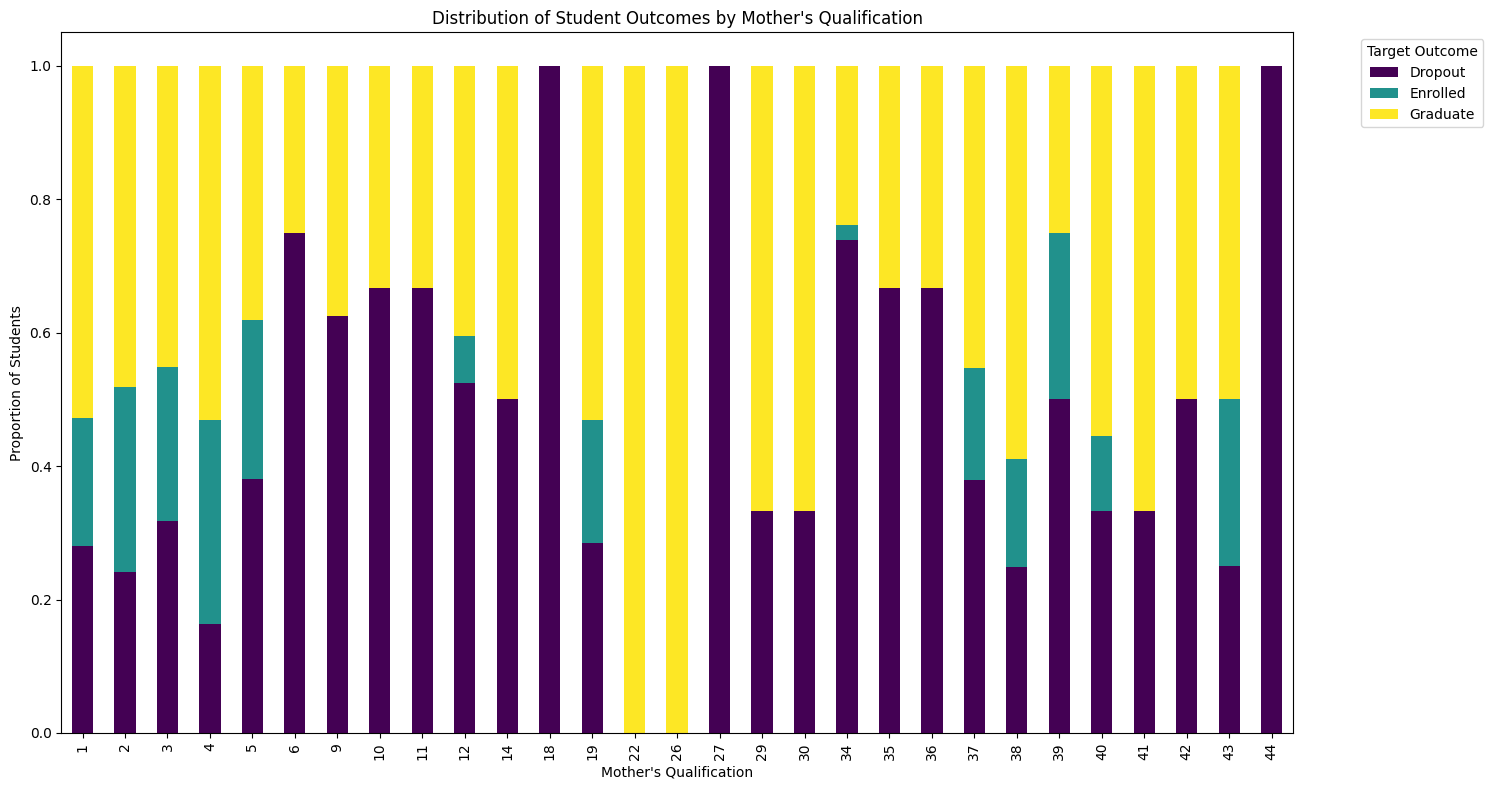

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a cross-tabulation to get counts of Target_Label for each Mother's Qualification
mom_qual_target_counts = pd.crosstab(df["Mother's qualification"], df['Target_Label'], normalize='index')

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
mom_qual_target_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(15, 8))

plt.title("Distribution of Student Outcomes by Mother's Qualification")
plt.xlabel("Mother's Qualification")
plt.ylabel('Proportion of Students')
plt.legend(title='Target Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

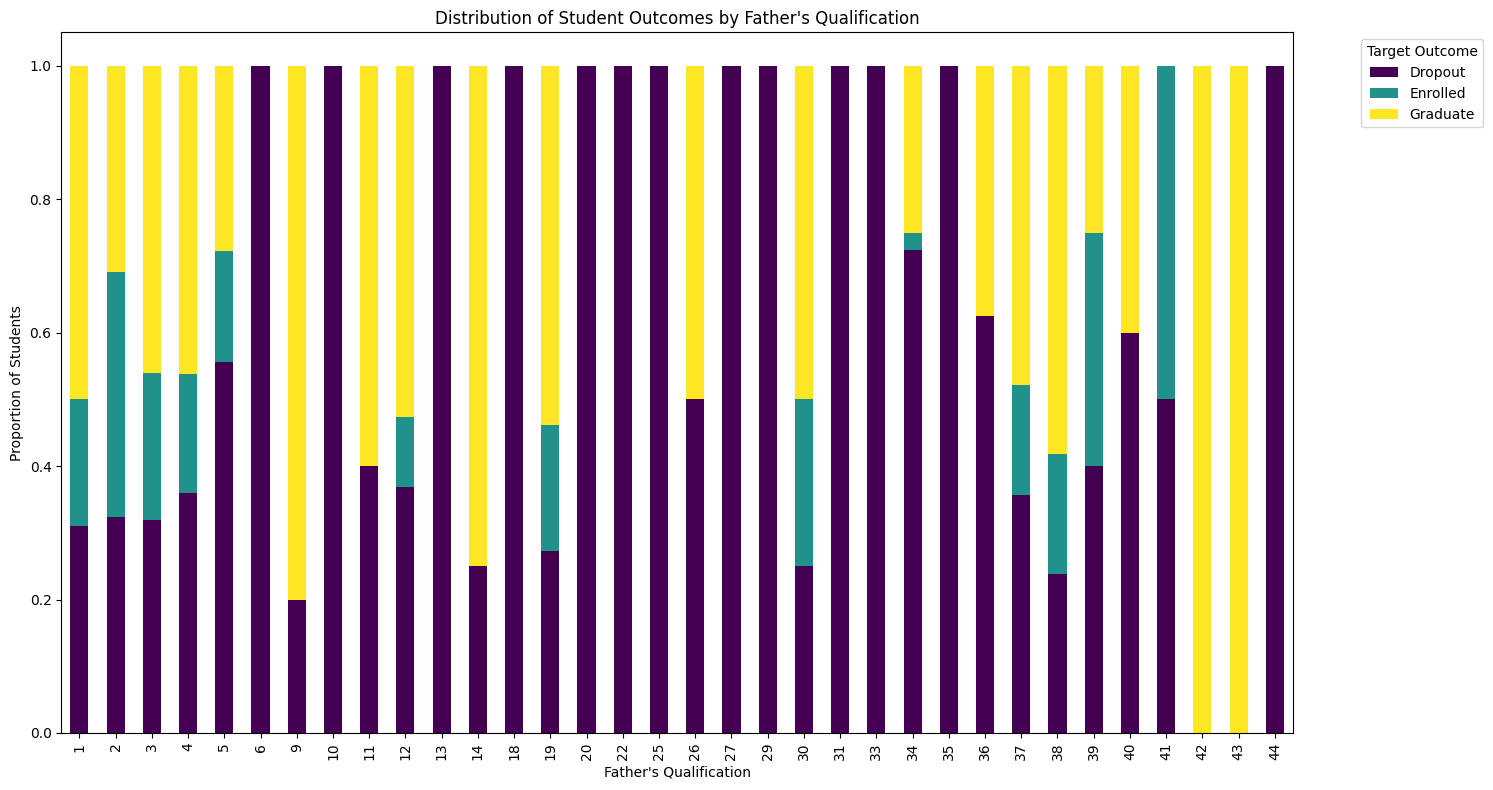

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a cross-tabulation to get counts of Target_Label for each Father's Qualification
father_qual_target_counts = pd.crosstab(df["Father's qualification"], df['Target_Label'], normalize='index')

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
father_qual_target_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(15, 8))

plt.title("Distribution of Student Outcomes by Father's Qualification")
plt.xlabel("Father's Qualification")
plt.ylabel('Proportion of Students')
plt.legend(title='Target Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This does appear to suggest that Qualification of Mothers are somewhat lacking in correlation. Yet, some have a much higher chance of being a dropout than other Qualifications, meaning Parents and their specialization can play a rol

**Data in need of Transformation:**



There are lots of features in this dataset that are categorical but are still represented using numbers. These include Marital Status, Mother Qualification, Father Qualification, Mother Occupation, Father Occupation, and many more. All of these variables are represented with a series of integers that fail to express or represent the nominal nature of these variables. As such, it makes sense to perform one-hot encoding and convert them to binary columns of 0s and 1s because it would clarify the meaning behind a lot of the data entries and make it easier to draw conclusions.

There are also a bunch of numerical variables that are continuous and should get some scaled. This would help prevent higher values from dominating.


#Turning Target into Binary Outcome (Esha)

In [ ]:
print(df['Target'].unique())

['Dropout' 'Graduate' 'Enrolled']


In [ ]:
(df['Target']).value_counts()
print((df['Target']))

0        Dropout
1       Graduate
2        Dropout
3       Graduate
4       Graduate
          ...   
4419    Graduate
4420     Dropout
4421     Dropout
4422    Graduate
4423    Graduate
Name: Target, Length: 4424, dtype: object


In [ ]:
df['Target'].value_counts(normalize=True)*100

,proportion
Target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


In [ ]:
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
# Turns 'Target' into binary (Not Dropout and Dropout)
df["dropout_binary"] = df["Target"].eq("Dropout").astype(int)
df[["dropout_binary"]].head()
df.groupby("Target")["dropout_binary"].unique()
y = df["dropout_binary"]

In [ ]:
print(df['dropout_binary'].unique())

[1 0]


In [ ]:
y.value_counts()
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
4419    0
4420    1
4421    1
4422    0
4423    0
Name: dropout_binary, Length: 4424, dtype: int64


In [ ]:
df['dropout_binary'].value_counts(normalize=True)*100

,proportion
dropout_binary,
0,67.879747
1,32.120253


In [ ]:
df['dropout_binary'].value_counts()

,count
dropout_binary,
0,3003
1,1421


# Creating Derived Features and T0, T1, T2 Timepoint Sets (Esha)

In [ ]:
# Creates derived feature pass rate for 1st semester and deals with missing values
df['pass_rate_1st'] = df['Curricular units 1st sem (approved)']/df['Curricular units 1st sem (enrolled)'].replace(0, np.nan)
df['pass_rate_1st'] = df['pass_rate_1st'].fillna(0)

# Creates derived feature engagement rate for 1st semester and deals with missing values
df['engagement_rate_1st'] = df['Curricular units 1st sem (evaluations)']/df['Curricular units 1st sem (enrolled)'].replace(0, np.nan)
df['engagement_rate_1st'] = df['engagement_rate_1st'].fillna(0)

# Creates derived feature without evaluations rate for 1st semester and deals with missing values
df['without_evaluations_rate_1st'] = df['Curricular units 1st sem (without evaluations)']/df['Curricular units 1st sem (enrolled)'].replace(0, np.nan)
df['without_evaluations_rate_1st'] = df['without_evaluations_rate_1st'].fillna(0)

# Creates derived feature pass rate for 2nd semester and deals with missing values
df['pass_rate_2nd'] = df['Curricular units 2nd sem (approved)']/df['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)
df['pass_rate_2nd'] = df['pass_rate_2nd'].fillna(0)


# Creates derived feature engagement rate for 2nd semester and deals with missing values
df['engagement_rate_2nd'] = df['Curricular units 2nd sem (evaluations)']/df['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)
df['engagement_rate_2nd'] = df['engagement_rate_2nd'].fillna(0)

# Creates derived feature without evaluations rate for 2nd semester and deals with missing values
df['without_evaluations_rate_2nd'] = df['Curricular units 2nd sem (without evaluations)']/df['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)
df['without_evaluations_rate_2nd'] = df['without_evaluations_rate_2nd'].fillna(0)

In [ ]:
# Creates t0_columns
t0_columns = [
   "Marital status", "Application mode", "Application order", "Course", "Daytime/evening attendance\t", "Previous qualification", "Previous qualification (grade)", "Nacionality", "Mother's qualification",
   "Father's qualification", "Mother's occupation", "Father's occupation", "Admission grade", "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", "Gender",
   "Scholarship holder", "Age at enrollment", "International", "Unemployment rate", "Inflation rate", "GDP"
]

# Creates t1_columns
t1_columns = t0_columns + [
    "Curricular units 1st sem (credited)",  "Curricular units 1st sem (enrolled)",  "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)", "pass_rate_1st","engagement_rate_1st","without_evaluations_rate_1st"
]

# Creates t2_columns
t2_columns = t1_columns + [
    "Curricular units 2nd sem (credited)",  "Curricular units 2nd sem (enrolled)",  "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)", "pass_rate_2nd","engagement_rate_2nd","without_evaluations_rate_2nd"
]


In [ ]:
# 't0_columns' contains the features available at T0
# Extracts those columns from the full dataframe to create X_T0
X_T0 = df[t0_columns]

# 't1_columns' contains the features available at T1
# Extracts those columns from the full dataframe to create X_T1
X_T1 = df[t1_columns]

# 't2_columns' contains the features available at T2
# Extracts those columns from the full dataframe to create X_T2
X_T2 = df[t2_columns]

#Preprocessing (Esha)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_pipeline(X, model):

  onehot_categorical_features = ["Mother's qualification","Father's qualification","Marital status","Application mode","Course","Nacionality","Application order", "Previous qualification", "Mother's occupation","Father's occupation",'Displaced','Educational special needs','Debtor','Tuition fees up to date','Gender','Scholarship holder','International','Daytime/evening attendance\t']

  numerical_features = ["Previous qualification (grade)", "Admission grade", "Age at enrollment", "Unemployment rate", "Inflation rate", "GDP", "Curricular units 1st sem (credited)",  "Curricular units 1st sem (enrolled)",  "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)", "pass_rate_1st","engagement_rate_1st","without_evaluations_rate_1st", "Curricular units 2nd sem (credited)",  "Curricular units 2nd sem (enrolled)",  "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)", "pass_rate_2nd","engagement_rate_2nd","without_evaluations_rate_2nd"]

  # Define categorical and numerical features
  onehot_idx = [c for c in onehot_categorical_features if c in X.columns]
  numerical_idx = [c for c in numerical_features if c in X.columns]

  # Create transformers for numerical and categorical features
  onehot_categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

  numerical_transformer =  Pipeline(steps=[
    ('scaler', StandardScaler())])

  # Apply transformers to features using ColumnTransformer
  preprocessor = ColumnTransformer(
        transformers=[
            ('onehot_idx',onehot_categorical_transformer, onehot_idx),
            ('numerical_idx', numerical_transformer, numerical_idx)
        ])

  # Create the pipeline
  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('model', model)
    ])

  return pipeline

# Baseline: Predict the majority class (Esha)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np

def evaluate_majority_baseline(X, y, label="", n_splits=5):

  # Creates a stratified k-fold splitter to ensure each fold keeps the same class proportions as the complete dataset
  stratified_K_fold  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

   # Lists to store average precision results for each fold
  rows = []

  # Counter - to label each fold
  fold = 1

  # Loops through each fold of the stratified split
  for train_idx, test_idx in stratified_K_fold .split(X, y):

    # Splits X and y into training and test sets
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Find the most common class in training
    majority_class = y_train.mode()[0]

    # Predict the majority class for All test samples
    y_prediction = np.full_like(y_test, majority_class)

    y_prediction_probability = np.where(y_prediction == majority_class, 1.0, 0.0)

    # Calculates average precision
    ap = average_precision_score(y_test, y_prediction_probability)

    # Stores average precision and auc results
    rows.append({
        "Timepoint Set": label,
        "Fold": fold,
        "AP": ap
    })

    # Increments to next fold
    fold +=1

  # Stores average average precision and auc across all folds
  rows.append({
      "Timepoint Set": label,
      "Fold": "Average",
      "AP": np.mean([r["AP"] for r in rows]),
  })

  # Returns list for each fold and average fold
  return rows

In [ ]:
rows_T0 = evaluate_majority_baseline(X_T0, y, label="T0")
rows_T1 =evaluate_majority_baseline(X_T1, y, label="T1")
rows_T2 =evaluate_majority_baseline(X_T2, y, label="T2")

# Creates dataframe to display the accuracy and f1 across all folds for T0, T1, and T2
df_T0 = pd.DataFrame(rows_T0)
df_T1 = pd.DataFrame(rows_T1)
df_T2 = pd.DataFrame(rows_T2)

In [ ]:
# Displays T0 dataframe
df_T0


,Timepoint Set,Fold,AP
0,T0,1,0.322034
1,T0,2,0.320904
2,T0,3,0.320904
3,T0,4,0.320904
4,T0,5,0.321267
5,T0,Average,0.321203


In [ ]:
# Displays T1 dataframe
df_T1

,Timepoint Set,Fold,AP
0,T1,1,0.322034
1,T1,2,0.320904
2,T1,3,0.320904
3,T1,4,0.320904
4,T1,5,0.321267
5,T1,Average,0.321203


In [ ]:
# Displays T2 dataframe
df_T2

,Timepoint Set,Fold,AP
0,T2,1,0.322034
1,T2,2,0.320904
2,T2,3,0.320904
3,T2,4,0.320904
4,T2,5,0.321267
5,T2,Average,0.321203


In [ ]:
# Creates dataframe to display the average accuracy and f1 across all folds for T0, T1, and T2
df_avg = pd.DataFrame([
    df_T0[df_T0["Fold"] == "Average"].iloc[0],
    df_T1[df_T1["Fold"] == "Average"].iloc[0],
    df_T2[df_T2["Fold"] == "Average"].iloc[0],
])

In [ ]:
# Displays average dataframe
df_avg

,Timepoint Set,Fold,AP
5,T0,Average,0.321203
5,T1,Average,0.321203
5,T2,Average,0.321203


##Recall@k and Precision@k Metrics for Baseline

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np

CAPACITIES = [0.05, 0.10, 0.20]

def evaluate_majority_baseline_k(X, y, label="", n_splits=5):

  # Creates a stratified k-fold splitter to ensure each fold keeps the same class proportions as the complete dataset
  stratified_K_fold  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

   # Lists to store average precision results for each fold
  rows = []
  fold = 1

  for train_idx, test_idx in stratified_K_fold .split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Find the most common class in training
    majority_class = y_train.mode()[0]

    # Predict the majority class for All test samples
    y_prediction = np.full_like(y_test, majority_class)

    y_prediction_probability = np.where(y_prediction == majority_class, 1.0, 0.0)

    idx = np.argsort(y_prediction_probability)[::-1]
    n = len(y_test)

    row = {"Timepoint Set": label, "Fold": fold}

    for cap in CAPACITIES:
      k = max(1, int(cap*n))
      top_k = idx[:k]


      row[f"R@{int(cap*100)}"] = np.sum(y_test.values[top_k])/np.sum(y_test)
      row[f"P@{int(cap*100)}"] = np.mean(y_test.values[top_k])

    rows.append(row)
    fold +=1

  avg = {"Timepoint Set": label, "Fold": "Average"}
  for cap in CAPACITIES:

    r_key = f"R@{int(cap*100)}"
    p_key = f"P@{int(cap*100)}"


    avg[r_key] = np.mean([r[r_key] for r in rows])
    avg[p_key] = np.mean([r[p_key] for r in rows])

  rows.append(avg)

  return rows

In [ ]:
rows_T0_k = evaluate_majority_baseline_k(X_T0, y, label="Baseline T0")
rows_T1_k =evaluate_majority_baseline_k(X_T1, y, label="Baseline T1")
rows_T2_k =evaluate_majority_baseline_k(X_T2, y, label="Baseline T2")

# Creates dataframe to display recall@K and precision@k across all folds for T0, T1, and T2
df_T0 = pd.DataFrame(rows_T0_k)
df_T1 = pd.DataFrame(rows_T1_k)
df_T2 = pd.DataFrame(rows_T2_k)

In [ ]:
df_avg_k_baseline = pd.DataFrame([
    df_T0[df_T0["Fold"] == "Average"].iloc[0],
    df_T1[df_T1["Fold"] == "Average"].iloc[0],
    df_T2[df_T2["Fold"] == "Average"].iloc[0],
])

In [ ]:
df_avg_k_baseline

,Timepoint Set,Fold,R@5,P@5,R@10,P@10,R@20,P@20
5,Baseline T0,Average,0.056294,0.363636,0.097816,0.315909,0.220269,0.354122
5,Baseline T1,Average,0.056294,0.363636,0.097816,0.315909,0.220269,0.354122
5,Baseline T2,Average,0.056294,0.363636,0.097816,0.315909,0.220269,0.354122


##Analysis:

The majority class baseline provides the same average precision score regardless of T0, T1, and T2 because the baseline ignores all features from the dataset. This baseline, simply predicts the most common outcome (non-dropout) for every student. Since, the overall class distribution does not change across the timepoints (T0, T1, and T2) the baseline's predictions and performance remain the same. This baseline provides a consistent reference.

#Candidate  Models (Esha)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

def tune_model(X, y, base_model, param_grid, label):
  pipe = build_pipeline(X, base_model)

  cv = KFold(n_splits=5, shuffle=True, random_state= SEED)

  grid = GridSearchCV(
      pipe,
      param_grid,
      cv=cv,
      scoring="average_precision",
      n_jobs=1,
  )

  grid.fit(X, y)

  print(f"\n Best parameters for {label}: {grid.best_params_}")

  best_model = grid.best_estimator_.named_steps["model"]
  return best_model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np
from sklearn.base import clone

def evaluate_model_cv(X, y, model, label="", n_splits=5):

  # Creates a stratified k-fold splitter to ensure each fold keeps the same class proportions as the complete dataset
  stratified_K_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

  # Lists to store Train metrics (determine overfit/underfit)
  train_ap_list = []


  # Lists to store Test metrics for each fold
  test_ap_list = []

  # Loops through each fold of the stratified split
  for train_idx, test_idx in stratified_K_fold .split(X, y):

    # Splits X and y into training and test sets
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Clone model to avoid leakage across folds
    model_fold = clone(model)

    # Builds new pipeline for fold (ensures no data leakage)
    pipeline = build_pipeline(X_train, model_fold)

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Predict on the training set
    y_train_probability = pipeline.predict_proba(X_train)[:, 1]

    # Calculates average precision and auc on training
    train_ap = average_precision_score(y_train, y_train_probability)

    # Adds the average precision and auc for the fold to the list created before
    train_ap_list.append(train_ap)


    # Predict on the test set
    y_test_probability = pipeline.predict_proba(X_test)[:, 1]

    # Calculates average precision and auc on test
    ap = average_precision_score(y_test, y_test_probability)


    # Adds the average precision and auc for the fold to the list created before
    test_ap_list.append(ap)



  # Returns the average metrics across all folds (gives stable estimate)
  return {
      "label": label,
      "train_ap_mean": np.mean(train_ap_list),
      "test_ap_mean": np.mean(test_ap_list),
      "gap": np.mean(train_ap_list) - np.mean(test_ap_list)

  }


##1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_base = LogisticRegression(
    penalty= "l2",
    solver="lbfgs",
    random_state= SEED,
    class_weight="balanced"
)

log_grid = {
    "model__max_iter":  [200,300],
    "model__C": [0.01, 0.1, 0.5, 0.75, 1, 10]
}

In [ ]:
best_log_t0 = tune_model(X_T0, y, log_base, log_grid, "Log_T0")
best_log_t1 = tune_model(X_T1, y, log_base, log_grid, "Log_T1")
best_log_t2 = tune_model(X_T2, y, log_base, log_grid, "Log_T2")


 Best parameters for Log_T0: {'model__C': 0.5, 'model__max_iter': 200}

 Best parameters for Log_T1: {'model__C': 0.5, 'model__max_iter': 200}

 Best parameters for Log_T2: {'model__C': 0.5, 'model__max_iter': 200}


In [ ]:
log_model_t0 = LogisticRegression(
    penalty= "l2",
    solver="lbfgs",
    random_state= SEED,
    class_weight="balanced",
    max_iter = 200,
    C = 0.5
)

In [ ]:
log_model_t1 = LogisticRegression(
    penalty= "l2",
    solver="lbfgs",
    random_state= SEED,
    class_weight="balanced",
    max_iter = 200,
    C = 0.5
)

In [ ]:
log_model_t2 = LogisticRegression(
    penalty= "l2",
    solver="lbfgs",
    random_state= SEED,
    class_weight="balanced",
    max_iter = 200,
    C = 0.5
)

In [ ]:
log_results_T0 = evaluate_model_cv(X_T0, y, log_model_t0, label="Logistic Model T0")
log_results_T1 = evaluate_model_cv(X_T1, y, log_model_t1, label="Logistic Model T1")
log_results_T2 = evaluate_model_cv(X_T2, y, log_model_t2, label="Logistic Model T2")

In [ ]:
results_df = pd.DataFrame([log_results_T0, log_results_T1, log_results_T2])
results_df

,label,train_ap_mean,test_ap_mean,gap
0,Logistic Model T0,0.769397,0.734166,0.035231
1,Logistic Model T1,0.880946,0.859943,0.021004
2,Logistic Model T2,0.905093,0.886151,0.018942


##2. Extreme Gradient Boosting

In [ ]:
%pip install xgboost
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    random_state= SEED
)

xgb_grid = {
    "model__learning_rate": [0.03, 0.1],
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [1,2]
}

In [ ]:
best_xgb_t0 = tune_model(X_T0, y, xgb_base, xgb_grid, "XGB_T0")
best_xgb_t1 = tune_model(X_T1, y, xgb_base, xgb_grid, "XGB_T1")
best_xgb_t2 = tune_model(X_T2, y, xgb_base, xgb_grid, "XGB_T2")


 Best parameters for XGB_T0: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}

 Best parameters for XGB_T1: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}

 Best parameters for XGB_T2: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}


In [ ]:
xgb_model_T0 = XGBClassifier(
    random_state= SEED,
    learning_rate = 0.1,
    max_depth = 2,
    n_estimators = 200
)

In [ ]:
xgb_model_T1 = XGBClassifier(
    random_state= SEED,
    learning_rate = 0.1,
    max_depth = 2,
    n_estimators = 200
)

In [ ]:
xgb_model_T2 = XGBClassifier(
    random_state= SEED,
    learning_rate = 0.1,
    max_depth = 2,
    n_estimators = 200
)

In [ ]:
xgb_results_T0 = evaluate_model_cv(X_T0, y, xgb_model_T0, label="XGB Model T0")
xgb_results_T1 = evaluate_model_cv(X_T1, y, xgb_model_T1, label="XGB Model T1")
xgb_results_T2 = evaluate_model_cv(X_T2, y, xgb_model_T2, label="XGB Model T2")

In [ ]:
results_df = pd.DataFrame([xgb_results_T0, xgb_results_T1, xgb_results_T2])
results_df

,label,train_ap_mean,test_ap_mean,gap
0,XGB Model T0,0.796929,0.747474,0.049455
1,XGB Model T1,0.895604,0.864262,0.031342
2,XGB Model T2,0.917068,0.889882,0.027186


## Decision

In [ ]:
results_df_T0 = pd.DataFrame([log_results_T0, xgb_results_T0])
results_df_T0

,label,train_ap_mean,test_ap_mean,gap
0,Logistic Model T0,0.769397,0.734166,0.035231
1,XGB Model T0,0.796929,0.747474,0.049455


In [ ]:
results_df_T1 = pd.DataFrame([log_results_T1, xgb_results_T1])
results_df_T1

,label,train_ap_mean,test_ap_mean,gap
0,Logistic Model T1,0.880946,0.859943,0.021004
1,XGB Model T1,0.895604,0.864262,0.031342


In [ ]:
results_df_T2 = pd.DataFrame([log_results_T2, xgb_results_T2])
results_df_T2

,label,train_ap_mean,test_ap_mean,gap
0,Logistic Model T2,0.905093,0.886151,0.018942
1,XGB Model T2,0.917068,0.889882,0.027186


Extreme Gradient Boosting is shown to be the better model as it achieve a higher overall mean average precision across all timepoints (T0, T1, and T2) than the Logistic Regression model.

Furthermore, Extreme Gradient Boosting is able to capture non-linear relationships that the Logistic Regression model cannot - therefore allowing it to capture more true dropout cases.

# Analytical Contribution (Jiyoun and Michael)

* Use the best model to run evaluation metrics, Recall@K and Precision@K




We'll use Extreme Gradient Boosting as our primary model since it demonstrates stronger overall classification performance and can capture nonlinear relationships.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Compute Recall@K and Precision@K
def recall_precision_at_k(y_true, y_scores, k):
  y_true = np.array(y_true)
  y_scores = np.array(y_scores)

  n = len(y_true)

  # Number of top samples to select based on K%
  top_k_n = max(1, int(np.ceil(n * k)))

  # Sort predicted scores in descending order
  sorted_idx = np.argsort(y_scores)[::-1]
  # Select indices of top K% highest-risk students
  top_k_idx = sorted_idx[:top_k_n]

  # Count how many selected students are actual dropouts
  true_positives = np.sum(y_true[top_k_idx] == 1)
  # Total number of actual dropouts in the dataset
  actual_positives = np.sum(y_true == 1 )

  # Recall@K : proportion of true dropouts captured in top K%
  recall_k = true_positives / actual_positives if actual_positives > 0 else 0.0
  # Precision@K : proportion of selected students who are actually dropouts
  precision_k = true_positives / top_k_n if top_k_n >0 else 0.0

  return recall_k, precision_k, top_k_n, actual_positives, true_positives

# Evaluate model using cross-validation and compute Recall@K and Precision@K
def evaluate_model_at_k_cv(X, y, model, k_values=[0.05, 0.10, 0.20], label="", n_splits=5):

    # Use stratified K-fold to preserve class distribution in each fold
    stratified_k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    rows = []

    # Store Recall@K and Precision@K for computing average
    avg_tracker = {k: {"recall": [], "precision": []} for k in k_values}

    fold = 1
    # Loop through each fold
    for train_idx, test_idx in stratified_k_fold.split(X, y):
        print(f"Processing {label} - Fold {fold}")

        # Split data into training and testing sets
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Clone model to avoid leakage across folds
        model_fold = clone(model)

        # Build pipeline
        pipeline = build_pipeline(X_train, model_fold)
        # Train the model
        pipeline.fit(X_train, y_train)

        # Get predicted probabilities for dropout
        y_scores = pipeline.predict_proba(X_test)[:, 1]

        # Compute metrics for each K value using the same predictions
        for k in k_values:
            recall_k, precision_k, selected_n, actual_dropouts, captured_dropouts = recall_precision_at_k(
                y_test, y_scores, k
            )

            # Store results for averaging
            avg_tracker[k]["recall"].append(recall_k)
            avg_tracker[k]["precision"].append(precision_k)

            # Store fold-level results
            rows.append({
                "Timepoint Set": label,
                "Fold": fold,
                "K": f"{int(k * 100)}%",
                "Selected": selected_n,
                "Actual Dropouts": actual_dropouts,
                "Captured Dropouts": captured_dropouts,
                "Recall@K": recall_k,
                "Precision@K": precision_k
            })

        fold += 1

    # Add average results across all folds for each K
    for k in k_values:
        rows.append({
            "Timepoint Set": label,
            "Fold": "Average",
            "K": f"{int(k * 100)}%",
            "Selected": np.nan,
            "Actual Dropouts": np.nan,
            "Captured Dropouts": np.nan,
            "Recall@K": np.mean(avg_tracker[k]["recall"]),
            "Precision@K": np.mean(avg_tracker[k]["precision"])
        })

    return rows

In [ ]:
# Run evaluation for all k values
xgb_k_results_T0 = evaluate_model_at_k_cv(X_T0, y, xgb_model_T0, k_values=[0.05, 0.10, 0.20], label="T0")
xgb_k_results_T1 = evaluate_model_at_k_cv(X_T1, y, xgb_model_T1, k_values=[0.05, 0.10, 0.20], label="T1")
xgb_k_results_T2 = evaluate_model_at_k_cv(X_T2, y, xgb_model_T2, k_values=[0.05, 0.10, 0.20], label="T2")

Processing T0 - Fold 1
Processing T0 - Fold 2
Processing T0 - Fold 3
Processing T0 - Fold 4
Processing T0 - Fold 5
Processing T1 - Fold 1
Processing T1 - Fold 2
Processing T1 - Fold 3
Processing T1 - Fold 4
Processing T1 - Fold 5
Processing T2 - Fold 1
Processing T2 - Fold 2
Processing T2 - Fold 3
Processing T2 - Fold 4
Processing T2 - Fold 5


In [ ]:
# Combine results into one dataframe
df_all = pd.concat([
    pd.DataFrame(xgb_k_results_T0),
    pd.DataFrame(xgb_k_results_T1),
    pd.DataFrame(xgb_k_results_T2)
], ignore_index=True)

# Extract average results
df_avg = df_all[df_all["Fold"].astype(str) == "Average"].copy()

# Round metrics to 3 decimal points
df_avg[["Recall@K", "Precision@K"]] = df_avg[["Recall@K", "Precision@K"]].round(3)

# Define correct order for k values and timepoint order
k_order = ["5%", "10%", "20%"]
timepoint_order = ["T0", "T1", "T2"]

df_avg["K"] = pd.Categorical(df_avg["K"], categories=k_order, ordered=True)
df_avg["Timepoint Set"] = pd.Categorical(df_avg["Timepoint Set"], categories=timepoint_order, ordered=True)


# Sort results for final display
df_avg = df_avg.sort_values(["K", "Timepoint Set"])
# Final table
df_avg[["Timepoint Set", "K", "Recall@K", "Precision@K"]]

,Timepoint Set,K,Recall@K,Precision@K
15,T0,5%,0.151,0.956
33,T1,5%,0.158,0.996
51,T2,5%,0.158,0.996
16,T0,10%,0.293,0.935
34,T1,10%,0.309,0.987
52,T2,10%,0.309,0.987
17,T0,20%,0.493,0.791
35,T1,20%,0.576,0.925
53,T2,20%,0.593,0.953


##Roc Curve (Michael)
Roc Curve Analysis for T0, T1, and T2 using Extreme Graident Boosting

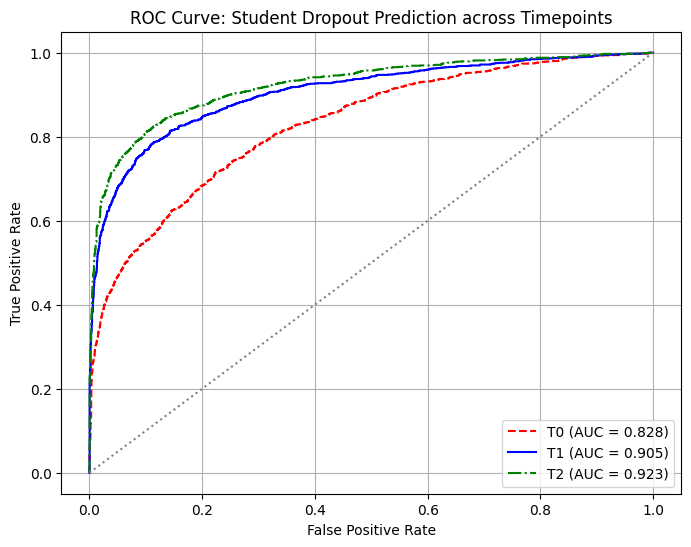

AUC T0: 0.828
AUC T1: 0.905
AUC T2: 0.923


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import numpy as np

SEED = 42

# Function to get cross validated predicted probabilities
def get_cv_probs(X, y, model, n_splits=5):
    stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    # Store probability for each sample
    y_probs = np.zeros(len(y))

    for train_idx, test_idx in stratified_kfold.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        # Clone model to avoid leakage across folds
        model_fold = clone(model)

        # Build pipeline for this fold
        pipeline = build_pipeline(X_train, model_fold)
        pipeline.fit(X_train, y_train)
        # Probability of dropout
        y_probs[test_idx] = pipeline.predict_proba(X_test)[:, 1]

    return y_probs


# Get predicted probabilities for each timepoint
y_probs_T0 = get_cv_probs(X_T0, y, xgb_model_T0)
y_probs_T1 = get_cv_probs(X_T1, y, xgb_model_T1)
y_probs_T2 = get_cv_probs(X_T2, y, xgb_model_T2)

# Function to compute FPR, TPR, AUC
def compute_roc(y_true, y_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Compute ROC for each timepoint
fpr_T0, tpr_T0, auc_T0 = compute_roc(y, y_probs_T0)
fpr_T1, tpr_T1, auc_T1 = compute_roc(y, y_probs_T1)
fpr_T2, tpr_T2, auc_T2 = compute_roc(y, y_probs_T2)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_T0, tpr_T0, label=f'T0 (AUC = {auc_T0:.3f})', color='red', linestyle='--')
plt.plot(fpr_T1, tpr_T1, label=f'T1 (AUC = {auc_T1:.3f})', color='blue', linestyle='-')
plt.plot(fpr_T2, tpr_T2, label=f'T2 (AUC = {auc_T2:.3f})', color='green', linestyle='-.')

plt.plot([0, 1], [0, 1], color='grey', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Student Dropout Prediction across Timepoints')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC values
print(f"AUC T0: {auc_T0:.3f}")
print(f"AUC T1: {auc_T1:.3f}")
print(f"AUC T2: {auc_T2:.3f}")


## Recall scores for K values (k= 5%, 10%, 20%) (Jiyoun)

At K = 5%

T0 : 0.151 \
T1 : 0.158 \
T2 : 0.158

It shows that there's almost no improvement across timepoints.
When capacity is very limited, acting later doesn't improve how many at-risk students we can identify.

---

At K = 10%

T0 : 0.293 \
T1 : 0.309 \
T2 : 0.309  

We notice small improvement from the results at 10% capacity, which means T1 already becomes slightly more useful than T0 with moderate capacity.


---

At K = 20%

T0 : 0.493 \
T1 : 0.576 \
T2 : 0.593  

The difference becomes meaningful with large capacity.
T1 improves largely over T0, and T2 improves slightly over T1.


## Precision scores for K values (k= 5%, 10%, 20%) (Jiyoun)

At K = 5%

T0 : 0.956\
T1 : 0.996\
T2 : 0.996

---

At K = 10%

T0 : 0.935\
T1 : 0.987\
T2 : 0.987

---

At K = 20%

T0 : 0.791\
T1 : 0.925\
T2 : 0.953



---
Precision scores are generally high across all timepoints, with noticeable improvement from T0 to T1 and T2, particularly at higher capacity levels.



## Analysis Summary (Jiyoun and Michael)



The results show that how effectively the model can prioritize at-risk students under different advising capacities and timepoints (T0, T1, T2).

Precision stays high across all timepoints with high improvement from T0 to later timepoints at large capacity levels. This pattern is more pronounced at higher capacity levels (K = 20%), where precision at T0 is noticeably lower compared to T1 and T2. This suggests that when more students are selected for intervention, early-stage information at T0 is less effective at accurately identifying true at-risk students. The substantial improvement from T0 to T1 indicates that academic performance data significantly enhances the reliability of prioritization under larger capacity.

However, recall is what primarily distinguishes the usefulness of intervention timing.

At very limited capacity (K=5%), recall remains relatively low and similar across T0, T1, and T2. It suggests that waiting for more academic information does not meaningfully improve targeting.

At moderate capacity (K=10%), T1 begins to show a small improvement over T0 in recall, which suggests that academic information from the first semester provides more meaningful information for identifying students at risk. Even though the improvement is small, it suggests that T1 is the earliest point where intervention becomes more reliable than T0. Additionally, we find that there is no improvement between T2 and T1, suggesting that waiting for additional information does not provide further benefit.

At higher capacity (K=20%), the difference becomes more prominent, where T1 significantly outperforms T0, while T2 only slightly improves over T1. This suggests that using data from T1 is much more effective than relying on T0. Waiting until T2 provides only slight additional benefit, indicating that delaying intervention offers minimal value.


The ROC curve shows that the T1 has significantly better performance than T0, and T2 indicates slightly better performance than T1. This finding also supports our claim that T1 is the best timepoint for the earliest academic intervention.

Overall, these results demonstrate that the effectiveness of dropout prediction depends on both intervention timing and capacity constraints. By evaluating models using a capacity-aware top-K approach, we find that T1 is the earliest timepoint where intervention becomes reliably effective. While T2 provides slightly better performance only with large advising capacity, the improvement is minimal, indicating that earlier intervention at T1 is optimal. T1 offers the best balance between intervention point and effectiveness for decision making.

Therefore, we recommend that academic advisors prioritize intervention starting at T1, as it provides the earliest point where predictions become reliably actionable without unnecessary delay.





#Calibration Check (Jiyoun)

To assess the reliability of predicted probabilities, we computed the Brier score across timepoints.

In [ ]:
from sklearn.metrics import brier_score_loss

def compute_brier_score_cv(X, y, model, label="", n_splits=5):
    stratified_k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = []

    for train_idx, test_idx in stratified_k_fold.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold = clone(model)
        pipeline = build_pipeline(X_train, model_fold)
        pipeline.fit(X_train, y_train)

        # predicted probabilities
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # compute Brier score
        score = brier_score_loss(y_test, y_prob)
        scores.append(score)

    return {
        "Timepoint": label,
        "Brier Score (mean)": np.mean(scores)
    }

In [ ]:
brier_T0 = compute_brier_score_cv(X_T0, y, xgb_model_T0, label="T0")
brier_T1 = compute_brier_score_cv(X_T1, y, xgb_model_T1, label="T1")
brier_T2 = compute_brier_score_cv(X_T2, y, xgb_model_T2, label="T2")

pd.DataFrame([brier_T0, brier_T1, brier_T2])

,Timepoint,Brier Score (mean)
0,T0,0.145534
1,T1,0.102715
2,T2,0.090755


The Brier Score measure the accuracy of predicted probabilities, where lower values indicate better-calibrated predictions.

The results show a clear improvement from T0 (0.146) to T1 (0.103) and T2 (0.091), indicating that probability estimates become more accurate as more academic information becomes available. This supports our findings that risk-based prioritization becomes more reliable starting from T1.


# Error Analysis (Talha)

**An Error analysis for T0 to compare False Positives and False Negatives under different top-K decision rules**

In [ ]:
# Filter T0 results to get fold-specific data (excluding 'Average' rows)
t0_fold_results = [r for r in xgb_k_results_T0 if r['Fold'] != 'Average']

k_values = [0.05, 0.10, 0.20]
error_data = []

for k in k_values:
    k_str = f"{int(k * 100)}%"

    # Filter results for the current K value
    results_for_k = [r for r in t0_fold_results if r['K'] == k_str]

    if results_for_k:
        # Calculate average 'Selected', 'Actual Dropouts', 'Captured Dropouts' across folds
        avg_selected = np.mean([r['Selected'] for r in results_for_k])
        avg_actual_dropouts = np.mean([r['Actual Dropouts'] for r in results_for_k])
        avg_captured_dropouts = np.mean([r['Captured Dropouts'] for r in results_for_k])

        # Calculate False Positives (FP) and False Negatives (FN)
        avg_false_positives = avg_selected - avg_captured_dropouts
        avg_false_negatives = avg_actual_dropouts - avg_captured_dropouts

        error_data.append({
            'K': k_str,
            'Average Selected': round(avg_selected),
            'Average Actual Dropouts': round(avg_actual_dropouts),
            'Average Captured Dropouts': round(avg_captured_dropouts),
            'Average False Positives': round(avg_false_positives),
            'Average False Negatives': round(avg_false_negatives)
        })

df_error_analysis_T0 = pd.DataFrame(error_data)

print(df_error_analysis_T0.to_markdown(index=False))

| K   |   Average Selected |   Average Actual Dropouts |   Average Captured Dropouts |   Average False Positives |   Average False Negatives |
|:----|-------------------:|--------------------------:|----------------------------:|--------------------------:|--------------------------:|
| 5%  |                 45 |                       284 |                          43 |                         2 |                       241 |
| 10% |                 89 |                       284 |                          83 |                         6 |                       201 |
| 20% |                177 |                       284 |                         140 |                        37 |                       144 |


At lower K values like 5%, the model is highly selective and gives less false positives (Predicted dropouts that didn't dropouts) but also way more false negatives (missed actual dropouts). As K increases, the model selects more students, generally leading to a decrease in false negatives but an increase in false positives

**Analysis of "Age at enrollment" among False Positive Cases**

In [ ]:
import seaborn as sns

def analyze_fp_age_at_enrollment_cv(X, y, model, k_threshold=0.20, n_splits=5):
    stratified_k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    all_fp_ages = []

    for train_idx, test_idx in stratified_k_fold.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold = clone(model)
        pipeline = build_pipeline(X_train, model_fold)
        pipeline.fit(X_train, y_train)

        y_scores = pipeline.predict_proba(X_test)[:, 1]

        # Get the number of top students to select based on k_threshold
        n_samples = len(y_test)
        top_k_n = max(1, int(np.ceil(n_samples * k_threshold)))

        # Sort predicted scores in descending order and get indices of top K%
        sorted_idx = np.argsort(y_scores)[::-1]
        top_k_predicted_idx = sorted_idx[:top_k_n]

        # Identify False Positives: predicted as top K% but actually not dropouts
        # These are students in the top_k_predicted_idx where y_test is 0 (not dropout)
        false_positive_mask = (y_test.iloc[top_k_predicted_idx] == 0)
        fp_indices_in_test_set = y_test.iloc[top_k_predicted_idx][false_positive_mask].index

        # Extract 'Age at enrollment' for these false positives
        fp_ages = X_test.loc[fp_indices_in_test_set, 'Age at enrollment'].tolist()
        all_fp_ages.extend(fp_ages)

    return all_fp_ages

# Perform the analysis for T0 using the Extreme Gradient Boosting model
fp_ages_T0 = analyze_fp_age_at_enrollment_cv(X_T0, y, xgb_model_T0, k_threshold=0.20)

# Convert to DataFrame for easier plotting and statistics
df_fp_ages_T0 = pd.DataFrame({'Age at enrollment': fp_ages_T0})

# Display some statistics for False Positive ages
display(df_fp_ages_T0.describe())


,Age at enrollment
count,185.000000
mean,28.064865
std,8.506143
min,18.000000
25%,21.000000
50%,26.000000
75%,33.000000
max,53.000000


This analyis implies shows a highly skewed distribution, with majority of age ranging between 18 and 33 even though the max is 53. It also does suggest greater number of false positives are on the upper end of undergraduate-aged Students.